# Exercise 4
### Computer Vision, Fall 2026
#### Name: <font color='blue'>*Sepeteus Rosenlöf*</font>
---
**Instructions:**
- Return the answer in PDF and Jupyter Notebook formats.

- Return latest on<font color='red'> Wednesday 30.9 at 16.00</font> via Moodle.
Disclosure, I used Gemini's guided learning to do these.

## Ex 4.1. Camera Calibration (2 p)
Please find the 3 sets of images provided in the Moodle page of this week's exercise. The three image sets (A,B and C) contain pictures taken of a camera calibration checkerboard pattern with a square size of 3cm.

1) Write a function using built-in OpenCV methods that computes the intrinsic camera calibration matrix and distortion matrix from a given set of calibration images.

2) Apply that function to all three sets of images and observe the results. Based on the results for the intrinsic and distortion matrix, discuss what type of camera or lens was used to capture the different image sets.


In [1]:
import cv2
import numpy as np
import os
import glob
from matplotlib import pyplot as plt
np.set_printoptions(suppress=True)


def calibrate(img_path):
    matrix=None
    distortion=None
    CHECKERBOARD = (6,8)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    #grid for internal corners
    grid = np.zeros((6 * 8, 3), np.float32)
    grid[:, :2] = np.mgrid[0:6, 0:8].T.reshape(-1, 2) * 3
    # print(np.shape(grid), grid[:3])
    
    images = glob.glob('{}/*.jpeg'.format(img_path))

    real_world_points = []
    image_world_points = []
    for filename in images:
        image = cv2.imread(filename)
        grayColor = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # print(np.shape(grayColor)) #4032, 3024
        ret, corners = cv2.findChessboardCorners(grayColor, CHECKERBOARD)
        if ret:
            real_world_points.append(grid)   
            refined_corners = cv2.cornerSubPix(grayColor, corners, (11, 11), (-1, -1), criteria)
            image_world_points.append(refined_corners)


    #identical images, no need to worry about grayColor
    ret, matrix, distortion, rvecs, tvecs = cv2.calibrateCamera(real_world_points, image_world_points, grayColor.shape[::-1], None, None)
    # print(ret)
        #...
    
    return matrix, distortion


print("Images A:")
matrix, distortion = calibrate("images-ex4/images_A")
print(matrix)
print(distortion)
print()

print("Images B:")
matrix, distortion = calibrate("images-ex4/images_B")
print(matrix)
print(distortion)
print()

print("Images C:")
matrix, distortion = calibrate("images-ex4/images_C")
print(matrix)
print(distortion)

Images A:
[[3440.39401054    0.         1606.30025712]
 [   0.         3438.45441212 1924.66106564]
 [   0.            0.            1.        ]]
[[ 0.20366693 -0.8915334  -0.00669965  0.0097696   2.01645179]]

Images B:
[[1707.80289242    0.         1477.72311222]
 [   0.         1704.50604133 1989.87378487]
 [   0.            0.            1.        ]]
[[-0.00571021  0.01908916 -0.00171764 -0.00362863 -0.00341247]]

Images C:
[[7567.67259765    0.         1286.73457325]
 [   0.         7594.40379902 2015.17108404]
 [   0.            0.            1.        ]]
[[ -0.17224666   9.05701331  -0.01414635  -0.00979423 -61.27838021]]


The images had narrowing fields of view in order of Images B having the widest field of view, Images A having the second, and Images C having the narrowest field of view.

Images C had barrel distortion. Images A had pincushion distortion, though there is an extremity with $k_3. Images C had minor barrel distortion, but the value is close enough to 0 that it could be said that they had minimal distortion.

The tangential distortion seems minimal for all.

I don't know about cameras, so I'm just going by the Gemini response:
- Low focal length ~1000–2000 px: Wide-angle lens
- Mid focal length ~3000–4000 px: Standard lens
- High focal length ~7000+ px: telephoto lens

#### Personal notes

- Internal corner = 2 black 2 white middle point.
- Intrinsic matrix models how 3D points in space are projected onto the 2D pixel grid of the camera sensor
- $$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$
- larger number means a long focal length / narrow field of view (like a telephoto or zoom lens). smaller number means a short focal length / wide field of view (like a wide-angle lens).
- $c_x$ and $c_y$ (Principal Point / Optical Center)
- $$D = \begin{bmatrix} k_1 & k_2 & p_1 & p_2 & k_3 \end{bmatrix}$$
- Radial Distortion ($k_1, k_2, k_3$, ball) -- Radial distortion occurs when light rays bend more at the edges of a curved lens than in its center.
- $k_1 < 0$ (Barrel Distortion): Straight lines bow outward away from the center. This is typical for wide-angle or fisheye lenses.
- $k_1 > 0$ (Pincushion Distortion): Straight lines bend inward toward the center. This is typical for telephoto lenses.
- $k_1 \approx 0$ (Minimal Distortion): Near-zero radial distortion, common in standard or high-quality rectified lenses.
- $k_1$ (Primary Radial Coefficient): Dominates near the center and mid-range of the image. It tells us the primary type of distortion (positive for pincushion, negative for barrel).
- $k_2$ & $k_3$ (Higher-Order Coefficients): Correct or fine-tune distortion near the outer edges and corners of the image frame. Extremely large magnitudes indicate overfitting during calibration or an extreme wide-angle/fisheye lens.
- Tangential Distortion ($p_1, p_2$ , triangle)
- $p_1 (x), p_2 (y) \approx 0$: Indicates good physical alignment inside the camera assembly.
- if the lens is slightly tilted relative to the sensor, some parts of the image appear closer (slightly enlarged) than they should be, while opposite parts appear further away
- Imagine aiming a red laser pointer perfectly through the middle of a magnifying glass. The point where the red beam lands on the paper behind it is the principal point

## Ex 4.2. Vanishing Points (4 p)

In this task you are given two images ("Corridor1.jpg" and "Corridor2.jpg"). Additionally, the code below provides you with the function "GetLines" which uses OpenCV's built-in HoughLines method to extract lines from images (You can look at the outputs of the function here: https://docs.opencv.org/3.4/d9/db0/tutorial_hough_lines.html)
The goal of this task is to find the vanishing point in the z-axis direction from the given images (we ignore a possible second vanishing point in y direction in this task). 

1) Implement the FilterLines function which should filter out all the lines which do NOT point into the z direction, that are e.g. all lines with an angle around 0 and 90 degrees.

2) Implement the GetVanishingPoint function using the filtered lines and the information from the lectures.

3) Plot the filtered lines and the vanishing point location within the image for visualization. 

In [26]:
import os
import cv2
import math
import numpy as np    

def FilterLines(lines):
    finalLines = []
    #find angles between 20 and 70 for line segments
    for line in lines:
        x1, y1, x2, y2 = line
        angle = np.arctan2((y2 - y1), (x2 - x1))
        angle = np.degrees(abs(angle)) % 180
        if angle > 90:
            angle = 180-angle
        if abs(angle) >= 20 and abs(angle) <= 70:
            finalLines.append(line)
    
    return finalLines
    

def GetLines(Image):
    # Read Image
    gray = cv2.cvtColor(Image, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (3, 3), 1)
    edges = cv2.Canny(gray_blur, 40, 255)

    # Find Lines
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 50, 10, 15)
    # Found lines?
    if lines is None:
        raise Exception("No Lines found!")
    
    # Filter lines
    filteredLines = FilterLines(lines)

    return filteredLines
    

def GetVanishingPoint(Lines):
    vanishingPoint = None
    M = []
    C = []
    for line in Lines:
        x1, y1, x2, y2 = line
        
        A = y2-y1
        B = -(x2-x1)
        C_val = A*x1 + B*y1
        M.append([A,B])
        C.append(C_val)

    vanishingPoint, _, _, _ = np.linalg.lstsq(M, C, rcond=None)
    return vanishingPoint

# Read corridor image
img = cv2.imread("./images-ex4/Corridor/Corridor1.jpg")    

# Get lines
lines = GetLines(img)

# Get vanishing point
vanishingPoint = GetVanishingPoint(lines)
vanishingPoint
# Check if successfull
if vanishingPoint is None:
    raise Exception("No Vanishing Point found")
    
# Visualize result
for line in lines:
    cv2.line(img, (line[0], line[1]), (line[2], line[3]), (0, 255, 0), 2)
cv2.circle(img, (int(vanishingPoint[0]), int(vanishingPoint[1])), 10, (0, 0, 255), -1)
cv2.imshow("Vanishing Point", img)
cv2.waitKey(0)

-1

## Ex 4.3. Manhattan Frames (2 p)

In the following task you are dealing with a concept called "Manhattan World", which is the assumption that man-made environments (indoors) are fundamentally organized in three orthogonal directions (characterized by three vanishing points). You can find more information on the Manhattan World in this article: "The Manhattan Frame Model—Manhattan World Inference in the Space of Surface Normals" (https://ieeexplore.ieee.org/document/7839295).

In the following task you are given the information of 2 vanishing directions (imgX_directionY) inside 2 consecutive frames.
Your first task is to compute both frame's third orthogonal vanishing direction and aggregate all 3 directions in a 3x3 matrix (Manhattan directions are columns).

After calculating the 3 vanishing directions, we want to calculate the relative rotational movement (3 degrees of freedom) of the camera between the two given frames based on Manhattan frames. In this special case, the only major rotation axis is the roll axis.
We assume the camera started at the first frame at an absolute orientation of the identity matrix (start_orientation).
At this starting point you observed the first three manhattan directions. At the time of the second image, you observe the second manhattan directions. First, calculate the absolute rotation at step 2, before computing the SO3 relative rotation matrix based on the absolute orientation. 

The code to evaluate your solution visually is given below. The scipy spatial transform package converts the SO3 rotation matrix you computed into euler angles in degrees. From the result we extract the roll angle and apply that to the original image. In the plot you can visualize your result to see if the rotated second image resembles the first image.
Careful: The given Manhattan directions are real measurements from a smartphone and, therefore, contain noise. That means even with the correct computation, the visual result does not align pixel level exact (but it still gives a good idea on whether your computations are correct).

In [28]:
import numpy as np
import cv2
from scipy.ndimage import rotate
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R

In [29]:
img1 = cv2.imread("./images-ex4/manhattan/1.jpg")
img2 = cv2.imread("./images-ex4/manhattan/2.jpg")

In [45]:
start_orientation = np.array([[1,0,0],[0,1,0],[0,0,1]])

img1_direction1 = np.array([0.031,-0.98,-0.17])
img1_direction2 = np.array([0.96,0.01,0.03])

img2_direction1 = np.array([0.944,-0.3,-0.14])
img2_direction2 = np.array([0.001,1.0,0.001])

img1_direction3 = np.cross(img1_direction1, img1_direction2)
img1_direction3 = img1_direction3 / np.linalg.norm(img1_direction3)

img2_direction3 = np.cross(img2_direction1, img2_direction2)
img2_direction3 = img2_direction3 / np.linalg.norm(img2_direction3)


array([-0.02898349, -0.17173503,  0.98471673])

In [53]:
# assemble Manhattan Matrices
R1 = np.stack((img1_direction1, img1_direction2, img1_direction3), axis=1)
R2 = np.stack((img2_direction1, img2_direction2, img2_direction3), axis=1)
R1, R2

(array([[ 0.031     ,  0.96      , -0.02898349],
        [-0.98      ,  0.01      , -0.17173503],
        [-0.17      ,  0.03      ,  0.98471673]]),
 array([[ 0.944     ,  0.001     ,  0.14634734],
        [-0.3       ,  1.        , -0.00113558],
        [-0.14      ,  0.001     ,  0.98923261]]))

In [56]:
# compute absolute rotation at image 2

In [59]:
# calculate the relative rotation from absolute orientation
R_relative = R2 @ R1.T

(3, 3)

In [90]:
#Be careful if you computed the rotation from image 1 -> image 2 or vica versa, try negating your angle
roll = R.from_matrix(R_relative).as_euler('xyz', degrees=True)
# roll=-roll
rotated= rotate(img1, roll[2],axes=(0,1), reshape=False,mode='constant',cval=0)

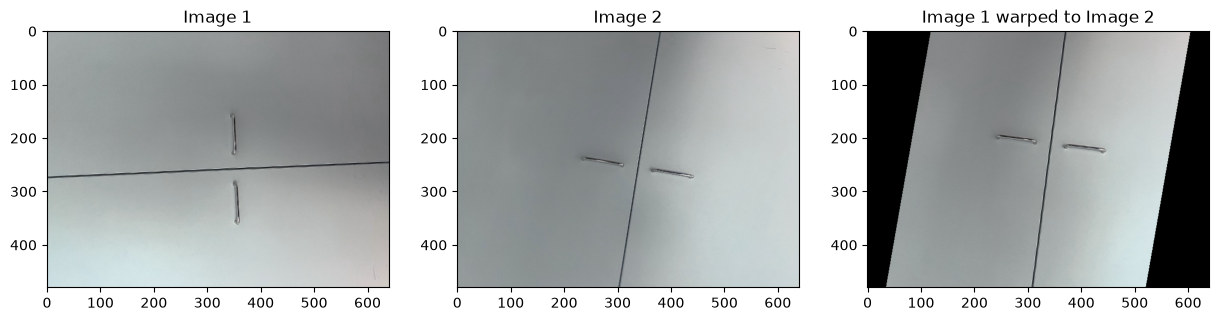

In [91]:
plt.figure(figsize=(15,30))
plt.subplot(1,3,1)
plt.title("Image 1")
plt.imshow(img1)
plt.subplot(1,3,2)
plt.title("Image 2")
plt.imshow(img2)
plt.subplot(1,3,3)
plt.title("Image 1 warped to Image 2")
plt.imshow(rotated)
plt.show()

### Personal notes

- Cross product can be used to find a vector that is orthogonal to both
- Because the camera starts at an orientation equal to the identity matrix ($R_0 = I$), the absolute orientation at frame 1 is simply $R_1$.